HEALTH LIFESTYLE PREDICTION 
      
      A health lifestyle prediction model will predict the disease_risk based on the feature : age,gender,bmi,daily_steps,sleep_hours,     water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history 



In [2]:
# Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("data/health_lifestyle_dataset.csv")

In [4]:
df.head()

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [5]:
df.drop(columns=['id'], inplace=True)


In [6]:
df.head(3)

,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   age                100000 non-null  int64  
 1   gender             100000 non-null  object 
 2   bmi                100000 non-null  float64
 3   daily_steps        100000 non-null  int64  
 4   sleep_hours        100000 non-null  float64
 5   water_intake_l     100000 non-null  float64
 6   calories_consumed  100000 non-null  int64  
 7   smoker             100000 non-null  int64  
 8   alcohol            100000 non-null  int64  
 9   resting_hr         100000 non-null  int64  
 10  systolic_bp        100000 non-null  int64  
 11  diastolic_bp       100000 non-null  int64  
 12  cholesterol        100000 non-null  int64  
 13  family_history     100000 non-null  int64  
 14  disease_risk       100000 non-null  int64  
dtypes: float64(3), int64(11), object(1)
memory usage: 11

In [8]:
df.shape

(100000, 15)

In [9]:
df.isna().sum()

age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

age                     62
gender                   2
bmi                    221
daily_steps          18921
sleep_hours             71
water_intake_l          46
calories_consumed     2800
smoker                   2
alcohol                  2
resting_hr              50
systolic_bp             90
diastolic_bp            60
cholesterol            150
family_history           2
disease_risk             2
dtype: int64

In [12]:
df.describe()

,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,48.525990,29.024790,10479.87029,6.491784,2.751496,2603.341200,0.200940,0.300020,74.457420,134.58063,89.508850,224.300630,0.299150,0.248210
std,17.886768,6.352666,5483.63236,2.021922,1.297338,807.288563,0.400705,0.458269,14.423715,25.95153,17.347041,43.327749,0.457888,0.431976
min,18.000000,18.000000,1000.00000,3.000000,0.500000,1200.000000,0.000000,0.000000,50.000000,90.00000,60.000000,150.000000,0.000000,0.000000
25%,33.000000,23.500000,5729.00000,4.700000,1.600000,1906.000000,0.000000,0.000000,62.000000,112.00000,74.000000,187.000000,0.000000,0.000000
50%,48.000000,29.000000,10468.00000,6.500000,2.800000,2603.000000,0.000000,0.000000,74.000000,135.00000,89.000000,224.000000,0.000000,0.000000
75%,64.000000,34.500000,15229.00000,8.200000,3.900000,3299.000000,0.000000,1.000000,87.000000,157.00000,105.000000,262.000000,1.000000,0.000000
max,79.000000,40.000000,19999.00000,10.000000,5.000000,3999.000000,1.000000,1.000000,99.000000,179.00000,119.000000,299.000000,1.000000,1.000000


In [13]:

# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features :{}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))


We have 14 numerical features :['age', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l', 'calories_consumed', 'smoker', 'alcohol', 'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'family_history', 'disease_risk']

We have 1 categorical features : ['gender']


In [14]:
df.corr(numeric_only=True)['disease_risk'].sort_values(ascending=False)


disease_risk         1.000000
resting_hr           0.005437
bmi                  0.003586
family_history       0.003225
calories_consumed    0.002737
sleep_hours          0.002582
age                  0.001671
smoker               0.001125
systolic_bp          0.001086
alcohol              0.000515
water_intake_l      -0.001902
daily_steps         -0.003444
diastolic_bp        -0.003774
cholesterol         -0.003941
Name: disease_risk, dtype: float64

In [15]:
df.groupby('smoker')['disease_risk'].mean() 
df.groupby('alcohol')['disease_risk'].mean(),
df.groupby('family_history')['disease_risk'].mean()


family_history
0    0.247300
1    0.250343
Name: disease_risk, dtype: float64

In [16]:
df['bp_ratio'] = df['systolic_bp'] / df['diastolic_bp']


In [17]:
df.head(2)

,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,bp_ratio
0,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,1.450450
1,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,1.784615


In [18]:
df['lifestyle_score'] = (
    df['daily_steps']/10000 +
    df['sleep_hours']/8 +
    df['water_intake_l']/3
)


In [19]:
df['high_bp'] = (df['systolic_bp'] > 140).astype(int)
df['high_cholesterol'] = (df['cholesterol'] > 240).astype(int)
df['obese'] = (df['bmi'] > 30).astype(int)


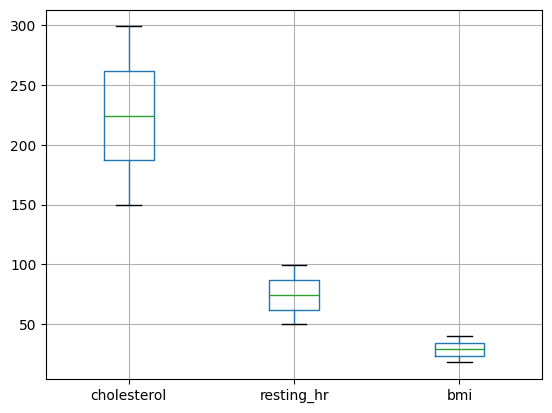

In [20]:
df.boxplot(column=['cholesterol', 'resting_hr', 'bmi'])
plt.show()


<Axes: xlabel='disease_risk'>

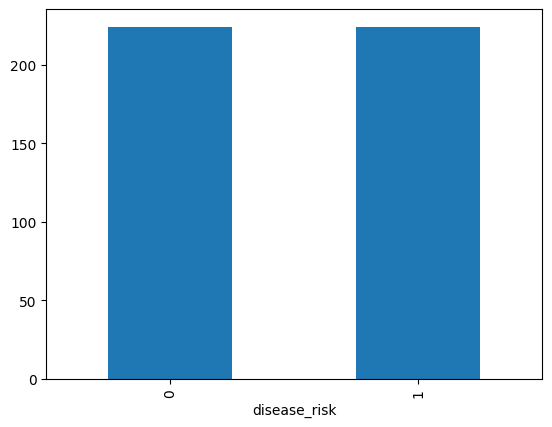

In [21]:
df.groupby('disease_risk')['cholesterol'].mean().plot(kind='bar')


<Axes: xlabel='bmi', ylabel='Count'>

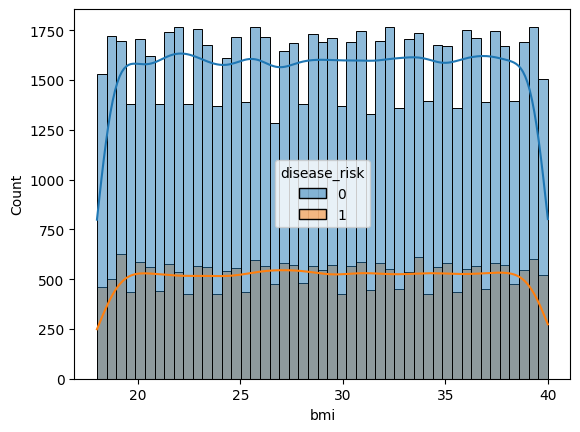

In [22]:
import seaborn as sns
sns.histplot(df, x='bmi', hue='disease_risk', kde=True)


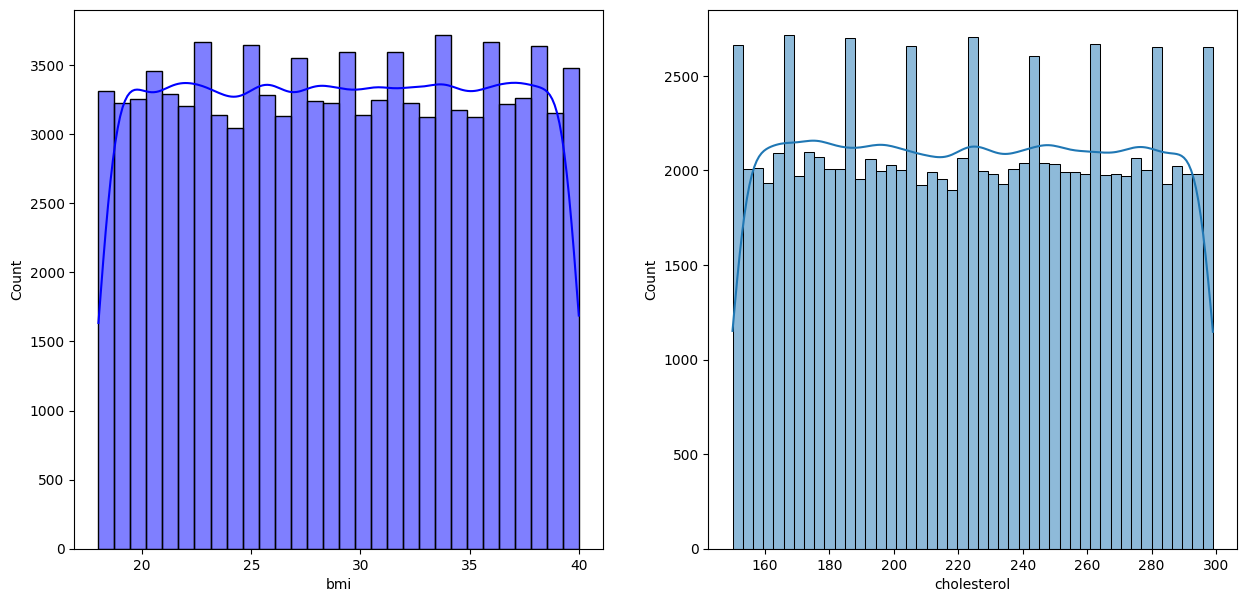

In [23]:
fig,axs = plt.subplots(1,2, figsize =(15, 7))
plt.subplot(121)
sns.histplot(data =df , x = 'bmi',bins = 30, kde =True,color='blue')
plt.subplot(122)
sns.histplot(data =df, x = 'cholesterol' , kde = True)
plt.show()

<Axes: title={'center': 'lifestyle_score'}, ylabel='lifestyle_score'>

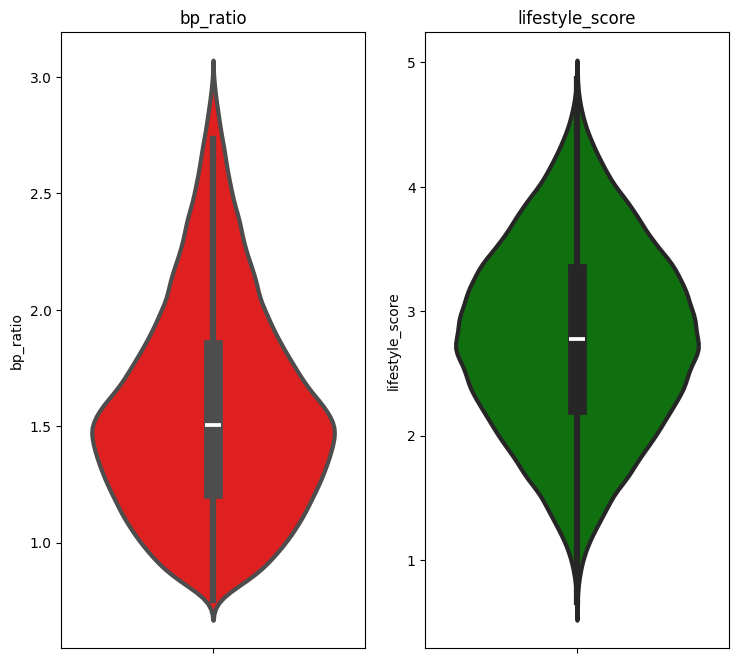

In [24]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('bp_ratio')
sns.violinplot(y='bp_ratio',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('lifestyle_score')
sns.violinplot(y='lifestyle_score',data=df,color='green',linewidth=3)


In [57]:
df['More_calories_consumed'] = df.groupby('disease_risk')['calories_consumed'].mean()


(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

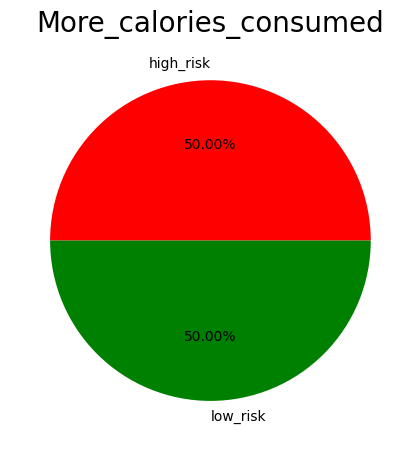

In [58]:
plt.rcParams['figure.figsize'] = (30,12)
plt.subplot(1,5,1)

size = df['More_calories_consumed'].value_counts()
labels = ['high_risk', 'low_risk']
colors = ['red', 'green']

plt.pie(size, labels=labels, colors=['red','green'],
        autopct='%.2f%%')
plt.title('More_calories_consumed', fontsize=20)
plt.axis('off')
